# Module 2: Epidemic Modeling of a Mystery Virus

## Team Members:
Zain Abed and Grace Lee

## Project Title:
Mystery Virus Epidemic Modeling

## Project Goal:
This project aims to model and examine the disease spread and outbreak of a "mystery virus" at UVA, comparing predicted disease models to real disease spread. The accuracy of the modeling techniques is evaluated, along with intervention strategies to slow disease spread.

The following questions are explored:
- How can the spread of an epidemic be modeled and predicted?
- What specific virus family could the disease be from?
- How can interventions ameliorate the spread and severity of the virus?

## 1. Data and disease background

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population

Prevalence and incidence were calculated around day 83, which was the peak day of infections. Prevalence is how many people have currently have the disease, and incidence is the rate that new cases are appearing. 

At day 83 which is the peak of disease spread, the point prevalence is 18.4% (3294/17,900). Incidence at peak day 83 is ((3294-3146)/17900)*1000 = 8.3 new cases per 1,000 people. 

* Economic burden (you can generalize from respiratory viruses)

Carrico et al. (2024) estimates an annual economic burden of 6.6 billion dollars due to the respiratory syncytial virus (RSV), which is a common respiratory virus causing cold-like symptoms. While RSV may or may not be the mystery virus, it is known that the mystery virus is also a respiratory disease with symptoms similar to RSV. The economic burden for a smaller-scale university population would be much less. However, it is important to realize the drastic economic implications of that a respiratory virus could have when spreading to a wider population. 

* Symptoms

From data briefings, a wide variety of symptoms present at different stages of the disease. Early symptoms include mild respiratory symptoms, with a few reports of sore throat, fatigue, and joint pain. Rash and low-grade fever were also reported, and gastrointestinal symptoms were reported in a few cases.

* Biological mechanisms

The "mystery virus" is about 50 to 80 nanometers in size. Transmission of the virus is through respiratory droplets, meaning infection occurs when a susceptible individual inhales respiratory droplets of an infected person. The virus enters a host cell, where it uses host cell machinery to create new copies of the viral genome. Newly assembled "virions" are then released out of the host cell to infect new cells. Because the virus is a positive-sense RNA virus, it does not need to undergo transcription (creating an mRNA template for protein formation). The virus is immediately able to undergo translation to form new viral proteins.

## 2. Data Analysis

### 2a. Methods
During the early disease spread, data was analyzed using a fitted exponential growth curve to predict the disease's R0. Later, an SEIR prediction model was used to estimate the disease's spread and behavior over time. Euler's method was used to solve the SEIR model, and the model's accuracy was optimized and evaluated through a sum of squares error (SSE) calculation. The model's predictions were mapped against true data values to examine the accuracy of the model.

In [2]:
# Generative AI tools were used in assistance of writing some portions of code and identifying bugs when they occured

#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
From Data Release #1, because the data was taken from early on into the infection, exponential growth was assumed. To estimate R0, `curve_fit` was used to make an exponential growth curve fitted to the plotted data points. Under the exponential growth assumption, R0 was calculated using R0 = e^(r*D), producing an R0 of 1.27.

**What is known:**
- Cases from the first 45 days of the outbreak
- Transmission occurs through respiratory droplets
- There is no evidence of pre-existing immunity

**What is unknown:**
- How long does it take a person to become infectious once exposed to the virus?
- How long does it take a person to recover from the disease?
- How many additional students can one person infect?

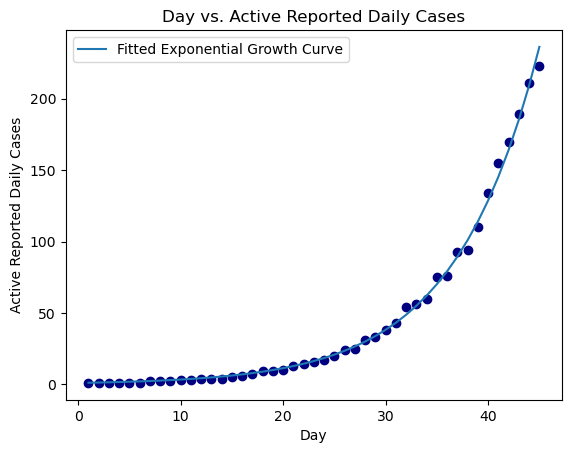

Estimated R0: 1.2749328499223294


In [3]:
#Importing Data Release #1
data = pd.read_csv("/Users/gracelee/Documents/computational BME/Module-2-Epidemics-SIR-Modeling_lee_abed/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

#Define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

#Fitting exponential growth model to the data.
x = data["day"]
y = data["active reported daily cases"]

param, covariance = curve_fit(exponential_growth, x, y)

# Plotting our data
plt.scatter(data["day"], data["active reported daily cases"], color = 'navy')
plt.plot(x, exponential_growth(x, *param), label='Fitted Exponential Growth Curve')
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("Day vs. Active Reported Daily Cases")
plt.legend()
plt.show()

# Approximate R0 using this fit
r0 = np.exp(param[0] * 2) # The infectious period is 2 days. Use e^(r * D) to estimate R0
print ("Estimated R0:", r0)

### Similar Viruses and Accuracy
The first closest virus is Seasonal Influenza, with an R0 of 1.3. It's highly contagiuous and causes fever coughing, fever, and fatigue. The best way to avoid it is by getting yearly immunizations. Another virus with a similar R0 value is the H1N1 variant of Influenza. It has very similar symptoms and is also easily preventable with an annual vaccine. 

Conversations with peers who got slightly different estimated values suggests that the R0 value calculated may not be very accurate. Using an exponential growth model to predict disease spread does not account for other important aspects such as the latent period between getting exposed and becoming infectious.

In the case of our early epidemic modeling from day 0 to 45, it is generally safe to assume exponential growth. However, exponential growth cannot possibly continue infinitely, as eventually the susceptible population will decrease, along with other factors (such as recovered populations, etc.) that decrease infection spread. With more datapoints to analyze and greater information regarding disease characteristics, a better modeling system can calculate a more accurate R0, which is done later below.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
Data now goes up to day 70, with a few new disease parameters helpful to better model the disease spread.

**New disease parameter information:**
 - The symptomatic period is ~5-9 days
 - The infectious period begins ~2 days before symptom onset
 - The incubation period is ~12-18 days

In order to determine the S, E, I, and R values needed to model the data, Euler's method was used to solve the ordinary differential equations to predict those population states.

In [4]:
data2 = pd.read_csv('/Users/gracelee/Documents/computational BME/Module-2-Epidemics-SIR-Modeling_lee_abed/Data/mystery_virus_daily_active_counts_RELEASE#2.csv')

# Total population size
N = 17900

#Creating an array to hold the timepoints (days)
timepoints = data2["day"]


#Initial conditions for the SEIR model
S0 = 17899
E0 = 1
I0 = 1
R0 = 0

#Function that finds the predicted number of susceptible, exposed, infectious, and recovered individuals at each timepoint based on the SEIR model equations and the input parameters
def SEIR_model(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
   #Initializing SEIR model parameters and lists to store values
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for t in timepoints:
        dS = -beta/N * I[t-1] * S[t-1]
        dE = beta/N * I[t-1] * S[t-1] - (sigma * E[t-1])
        dI = sigma * E[t-1] - (gamma * I[t-1])
        dR = gamma * I[t-1]

        S.append(S[t-1]+dS)
        E.append(E[t-1]+dE)
        I.append(I[t-1]+dI)
        R.append(R[t-1]+dR)
    return (np.array(S), np.array(E), np.array(I), np.array(R))

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
Using a grid search, the SEIR model was optimized to best fit the data and to determine the best beta, gamma, and sigma values.

**How were search ranges for beta, sigma, and gamma picked?**
- Beta = contact rate * transmission probability

Both contact rates and transmission probabilities are unknown, so a wide range between 0.2 to 1.5 was chosen for the grid search based on a few beta values for different diseases found searching on the internet.

- Sigma = 1/latent period

Latent period is the time it takes from exposure to becoming infectious. From data briefings, the incubation period (the time from exposure to expressing symptoms) is around 12-18 days, and people become infectious about 2 days before showing symptoms. Therefore, the latent period should be the infectious period subtracted from the incubation period. 
This led to a latent period range of 10-16 days, which helped narrow the range of sigma to be values between 1/16 and 1/10. 

- Gamma = 1/infectious period

The infectious period includes the 2 days before symptoms start, and contagiousness is assumed to continue for the duration of symptoms (5-9 days). Therefore, the infectious period is estimated to be in the range of 7 to 11 days. Values that are tested for gamma will consequently range from 1/11 to 1/7. 

These estimates and assumptions determined the range of values searched in the following grid-search optimization. The optimal beta, sigma, and gamma values were determined by finding the model with the lowest SSE.

In [5]:
def optimize(timepoints, N, S0, E0, I0, R0, data2):
    # Define the predicted ranges for beta, sigma, and gamma
    beta = np.arange(.2, 1.5, .01) #Wide range of values for beta to test, as the contagiousness is unknown
    sigma = np.arange(1/16, 1/10, .001) #narrower range of sigma values, as we know the incubation period is 12-18 days, and the infectious period - the infectious period before symptom onset would equal a latent period of 10-16 days
    gamma = np.arange(1/11, 1/7, .001) #narrower range of gamma values, as we know the infectious period (pre-symptomatic infectious period + symptom duration) is between 7 and 11 days, so gamma should be between 1/11 and 1/7
    
    beta_index = []
    sigma_index = []
    gamma_index = []

    SSE = []
    infections = data2["active reported daily cases"]

    for b in beta:
        for s in sigma:
            for g in gamma:
                predicted = SEIR_model(b, s, g, S0, E0, I0, R0, timepoints, N)
                n = len(infections)
                I = predicted[2][1:n+1] #Extracting the predicted number of infectious individuals at each timepoint from the SEIR model output
                sse_calc = np.sum((I-infections)**2)
                SSE.append(sse_calc)
                beta_index.append(b)
                sigma_index.append(s)
                gamma_index.append(g)

    best_idx   = np.argmin(SSE)
    best_beta  = beta_index[best_idx]
    best_sigma = sigma_index[best_idx]
    best_gamma = gamma_index[best_idx]
    best_sse   = SSE[best_idx]

    return best_beta, best_sigma, best_gamma, best_sse



best_beta, best_sigma, best_gamma, best_sse = optimize(timepoints, N, S0, E0, I0, R0, data2)

print(f"Best beta: ",  best_beta)
print(f"Best sigma: ", best_sigma)
print(f"Best gamma: ", best_gamma)
print(f"Best SSE: ",   best_sse)

Best beta:  0.9300000000000006
Best sigma:  0.0625
Best gamma:  0.14190909090909096
Best SSE:  101619.14302231715


### 2e. Plot the model-predicted infections over time compared to the data.
The predicted infections from the optimized SEIR model was compared to the actual infections obtained from Data Release #2. 

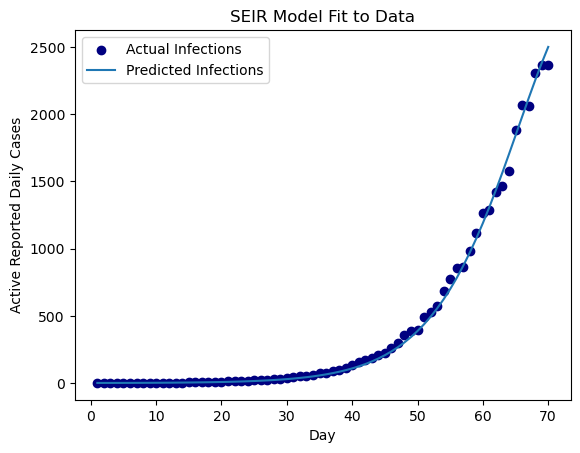

In [6]:
plt.scatter(timepoints, data2["active reported daily cases"], label="Actual Infections", color = 'navy')
predicted = SEIR_model(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints, N)
plt.plot(timepoints, predicted[2][1:len(timepoints)+1], label="Predicted Infections")
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.
The SEIR model was run until day 120 to estimate the future progression and spread of the disease. Cases are predicted to peak at day 78, with 2991 cases.

Peak day: 78
Peak active cases: 2990.6275883892295


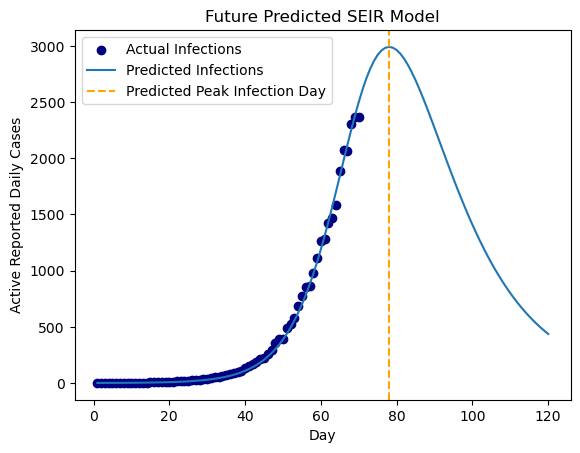

In [7]:
future_timepoints = np.arange(1,121)
future_predicted = SEIR_model(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, future_timepoints, N)
plt.scatter(timepoints, data2["active reported daily cases"], label="Actual Infections", color = 'navy')
plt.plot(future_timepoints, future_predicted[2][1:len(future_timepoints)+1], label="Predicted Infections")
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("Future Predicted SEIR Model")


# Pull predicted infected values
predicted_I = future_predicted[2][1:len(future_timepoints)+1]

# Find peak infections
peak_cases = np.max(predicted_I)

# Find index of peak
peak_index = np.argmax(predicted_I)

# Corresponding day
peak_day = future_timepoints[peak_index]

#Printing peak day and cases
print("Peak day:", peak_day)
print("Peak active cases:", peak_cases)

plt.axvline(x=peak_day, color='orange', linestyle='--', label='Predicted Peak Infection Day') #Demonstrates when the SEIR model predicted cases to peak

#Printing the graph
plt.legend()
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.
With more information from data release #3, the full 120 days of data were plotted below and compared to the predicted SEIR model.

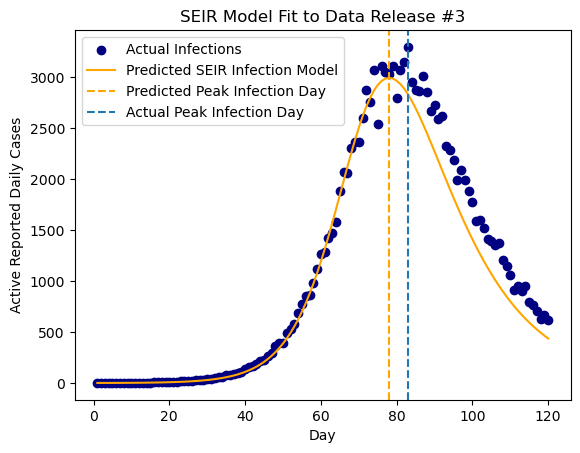

In [8]:
#Retrieving the third data release
data3 = pd.read_csv('/Users/gracelee/Documents/computational BME/Module-2-Epidemics-SIR-Modeling_lee_abed/Data/mystery_virus_daily_active_counts_RELEASE#3.csv')

#The extended timepoints from the third data release
timepoints3 = data3["day"]

#Actual number of infections taken from data release #3
plt.scatter(data3["day"], data3["active reported daily cases"], label="Actual Infections", color = 'navy')

#Predicted number of infections, based on the SEIR model
plt.plot(future_timepoints, future_predicted[2][1:len(future_timepoints)+1], label="Predicted SEIR Infection Model", color = 'orange')
plt.axvline(x=peak_day, color='orange', linestyle='--', label='Predicted Peak Infection Day') #Demonstrates when the SEIR model predicted cases to peak
plt.axvline(x=83, linestyle='--', label='Actual Peak Infection Day') #Demonstrates when cases actually peaked

#Labeling the graph
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("SEIR Model Fit to Data Release #3")
plt.legend()
plt.show()

### 2h. Intervention strategies for new outbreak at VT (70 days of infection)

Five intervention strategies are explored below: masking, a vaccine campaign, vaccine rollouts, quarantining, and school closure. These strategies were implemented 70 days into the infection. 

In [22]:
#Setting the baseline parameters for the SEIR model using VT's population size and determining values of S, E, I and R on day 70
N_VT = 31000 #Rough population size of Virginia Tech's undergraduates
day70 = SEIR_model(best_beta, best_sigma, best_gamma, N_VT, E0, 1, 0, timepoints, N_VT) #Runs the SEIR model to find S, E, I, and R predicted values on day 70, which will be used as initial conditions for intervention models that take place after day 70
S70 = day70[0][70] #Susceptible population on day 70
E70 = day70[1][70] #Exposed population on day 70
I70 = day70[2][70] #Infectious population on day 70
R70 = day70[3][70] #Recovered population on day 70

baseline = SEIR_model(best_beta, best_sigma, best_gamma, N_VT, E0, 1, 0, future_timepoints, N_VT) #SEIR model if no interventions are enacted
baseline_I = baseline[2][1:121] #Predicted infections with no intervention implemented
baseline_peak_cases = np.max(baseline_I) #Finding the peak number of cases with no intervention implemented

#### Masking as an intervention strategy:
The following code examines the effect that masking would have on VT's disease spread after day 70. Masks are predicted to reduce disease transmission rate by 40%, which means that the beta value is reduced by 40%. An SEIR model modeling mask intervention was run from day 70 to 120, using the reduced calculated beta value.

In [16]:
post_int = np.arange(1,51) #The time period after interventions are implemented is 50 days

mask_beta = 0.6*best_beta #Masking is estimated to reduce the transmission rate by 40%, as calculated below
mask_int = SEIR_model(mask_beta, best_sigma, best_gamma, S70, E70, I70, R70, post_int, N_VT) #Running the SEIR model with a reduced beta value to simulate the effect of mask intervention starting on day 70


mask_I = np.concatenate((day70[2][1:71], mask_int[2][1:51])) #Predicted infections with masking intervention implemented

mask_peak_cases = np.max(mask_I) #Finding the peak number of cases with masking intervention

#### Vaccine campaign as an intervention strategy:

A vaccine campaign enables a large portion of the population to become vaccinated and build immunity to the disease. This intervention model assumes 2000 students get vaccinated from the campaign, with a vaccine efficacy of 90%. The number of successfully vaccinated people are effectively moved from the susceptible population to recovered to simulate their new immunity.

In [17]:

vaccine_campaign = 0.9*2000 #2000 vaccines are distributed with 90% efficacy
vaccine_int = SEIR_model(best_beta, best_sigma, best_gamma, S70-vaccine_campaign, E70, I70, R70+vaccine_campaign, post_int, N_VT) #Running the SEIR model with the reduced susceptible population and increased recovered population to simulate the effect of vaccination intervention starting on day 70

vaccine_campaign_I = np.concatenate((day70[2][1:71], vaccine_int[2][1:51])) #Predicted infections with vaccine campaign intervention implemented
vaccine_peak_cases = np.max(vaccine_campaign_I) #Finding the peak number of cases with vaccine campaign intervention

#### Vaccine Rollout as an intervention strategy:

This intervention model assumes 1000 students get vaccinated on day 70, day 80, and day 90. To model this, new predicted S, E, I, and R values were found after each rollout. The susceptible and recovered populations were modified after each rollout.

In [18]:
vaccinerollout = 1000*.9 #Assuming 1000 vaccines are distributed on a particular day with 90% efficacy
every10days = np.arange(1,11) #Length between rollouts was 10 days

v_roll70 = SEIR_model(best_beta, best_sigma, best_gamma, S70-vaccinerollout, E70, I70, R70+vaccinerollout, every10days, N_VT) #Running the SEIR model with the reduced susceptible population and increased recovered population to simulate the effect of vaccination intervention starting on day 70 with 1000 vaccines distributed every 10 days

vS80 = v_roll70[0][10]-vaccinerollout #New predicted susceptible population on day 80, after first vaccine rollout on day 70
vE80 = v_roll70[1][10] #Predicted exposed population on day 80
vI80 = v_roll70[2][10] #Predicted infectious population on day 80
vR80 = v_roll70[3][10]+vaccinerollout #New predicted recovered population on day 80, after first vaccine rollout on day 70

v_roll80 = SEIR_model(best_beta, best_sigma, best_gamma, vS80, vE80, vI80, vR80, every10days, N_VT) #Running the SEIR model with the new predicted values of S and R on day 80 as the initial conditions to simulate the continued effect of vaccination intervention with 1000 vaccines distributed every 10 days after day 80

vS90 = v_roll80[0][10]-vaccinerollout #New predicted susceptible population on day 90, after second vaccine rollout on day 80
vE90 = v_roll80[1][10] #Predicted exposed population on day 90
vI90 = v_roll80[2][10] #Predicted infectious population on day 90
vR90 = v_roll80[3][10]+vaccinerollout #New predicted recovered population on day 90, after second vaccine rollout on day 80

day90to120 = np.arange(1,31) #Length after day 90 rollout to simulate is 30 days, from day 90 to day 120

v_roll90 = SEIR_model(best_beta, best_sigma, best_gamma, vS90, vE90, vI90, vR90, day90to120, N_VT) #Running the SEIR model with the new predicted values of S and R on day 90 as initial parameters
vaccine_rollout_I = np.concatenate((day70[2][1:71], v_roll70[2][1:11], v_roll80[2][1:11], v_roll90[2][1:31])) #Predicted infections with vaccine rollout intervention implemented

rollout_peak_cases = np.max(vaccine_rollout_I) #Finding the peak number of cases with vaccine rollout intervention


#### Quarantining as an intervention strategy:

By quarantining and isolating, it is assumed that the infectious period, the length a person is able to spread the disease, lowers by 2 days. The infectious period only decreases by 2 days to account for lag time in testing, and poor compliance.

In [19]:
infectious_period = 1/best_gamma #Calculating original infectious period based on the optimized gamma value
new_infectious_period = infectious_period - 2 
new_gamma = 1/new_infectious_period #Determines the new gamma value based on a reduced infectious period

quarantine_int = SEIR_model(best_beta, best_sigma, new_gamma, S70, E70, I70, R70, post_int, N_VT) #Running the SEIR model with the new gamma value
quarantine_I = np.concatenate((day70[2][1:71], quarantine_int[2][1:51])) #Quarantine intervention implemented

quarantine_peak_cases = np.max(quarantine_I) #Finding the peak number of cases with quarantine intervention implemented

#### School closure as an intervention strategy:
The following code models what would happen if school was shut down for two weeks, reducing contacts to 20%, which would in turn reduce beta by 20%. After a two week period, beta returns to its original value.

In [20]:
closure_beta = 0.2*best_beta #Assuming contact rate is 20% of the original contact rate due to quarantine measures
twoweeks = np.arange(1,15)
school_closure_int = SEIR_model(closure_beta, best_sigma, best_gamma, S70, E70, I70, R70, twoweeks, N_VT) #Running the SEIR model with the reduced beta value to simulate the effect of school closure intervention starting on day 70, using the predicted values of S, E, I, and R on day 70 as the new initial conditions for the model after the intervention

#New susceptible, exposed, infected, and receovered populations on day 84, after 2 weeks of school closure
closureS = school_closure_int[0][14] 
closureE = school_closure_int[1][14]
closureI = school_closure_int[2][14]
closureR = school_closure_int[3][14]

reopened_period = np.arange(1,37) #Remaining time when school is reopened from day 85 to day 120 is 36 days

reopening = SEIR_model(best_beta, best_sigma, best_gamma, closureS, closureE, closureI, closureR, reopened_period, N_VT) #Running the SEIR model with the original beta value and the new predicted values of S, E, I, and R on day 85 as the initial conditions to simulate the effect of reopening after 2 weeks of school closure

closure_I = np.concatenate((day70[2][1:71], school_closure_int[2][1:15], reopening[2][1:37])) #School closure intervention implemented for 2 weeks, followed by reopening

closure_peak_cases = np.max(closure_I) #Finding the peak number of cases with school closure intervention implemented for 2 weeks, followed by reopening


#### Examining predicted epidemic spread using these interventions - zain
The SEIR models with interventions implemented were plotted against the baseline SEIR model for when no interventions were added.

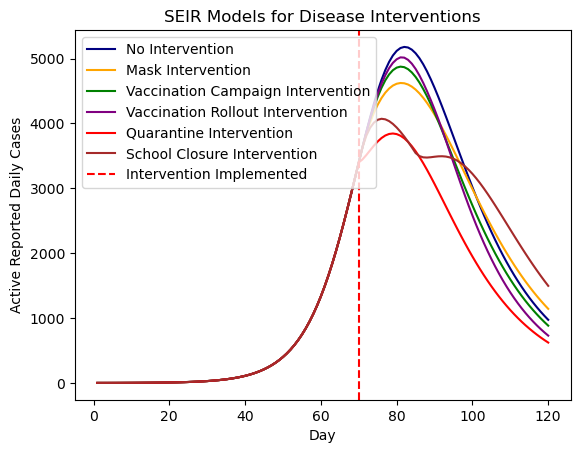

Peak cases with no intervention: 5179.0169871592025
Peak cases with mask intervention: 4623.0389294582965
Peak cases with vaccination campaign intervention: 4875.298108796573
Peak cases with vaccination rollout intervention: 5018.0970763465875
Peak cases with quarantine intervention: 3844.7809460346366
Peak cases with school closure intervention: 4071.6253268691034


In [23]:
#Plotting the predicted number of infections for each intervention model compared to the baseline model with no intervention
plt.plot(future_timepoints, baseline_I, label="No Intervention", color = 'navy')
plt.plot(future_timepoints, mask_I, label="Mask Intervention", color = 'orange')
plt.plot(future_timepoints, vaccine_campaign_I, label="Vaccination Campaign Intervention", color = 'green')
plt.plot(future_timepoints, vaccine_rollout_I, label="Vaccination Rollout Intervention", color = 'purple')
plt.plot(future_timepoints, quarantine_I, label="Quarantine Intervention", color = 'red')
plt.plot(future_timepoints, closure_I, label="School Closure Intervention", color = 'brown')

plt.axvline(x=70, color='red', linestyle='--', label='Intervention Implemented') #Day interventions are implemented

#Labeling the graph
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("SEIR Models for Disease Interventions")
plt.legend()
plt.show()

#Printing the peak cases for each intervention model
print("Peak cases with no intervention:", baseline_peak_cases)
print("Peak cases with mask intervention:", mask_peak_cases)
print("Peak cases with vaccination campaign intervention:", vaccine_peak_cases)
print("Peak cases with vaccination rollout intervention:", rollout_peak_cases)
print("Peak cases with quarantine intervention:", quarantine_peak_cases)
print("Peak cases with school closure intervention:", closure_peak_cases)

Analyzing the effectiveness of intervention by how much it lowered the peak number of daily cases, it is shown that quarantining was the most effective intervention strategy, followed by school closure and masking interventions. However, it should be noted that while school closure dampened the case number peak, there seemed to be a second resurgence in cases after schools reopened. It also seems to lengthen the duration of epidemic spread, dragging cases out for longer.

Both the vaccine campaign and rollout performed the worst out of the interventions modeled.

Additionally, it should be noted that the real-life effectiveness of interventions depends on compliance and behavior of students. If students do not adhere to quarantining guidelines, or fail to mask up, the model predictions will be very different from real case amounts. 

## Verify and validate the analysis: 

#### Error in the SEIR Model

Relative error is calculated by $$\frac{|Actual Value - Measured|}{Actual Value} \times 100\%$$

The code based on Data Release #2 estimated cases to peak at day 78, with 2991 cases. Referring to Data Release #3, the true peak was at day 83, with 3294 cases. Using this information, the relative error in y and x of the predicted SEIR model was calculated using Desmos.

Error in peak number of cases (error in y): **9.199%**

Error in day of peak case number (error in x): **6.024%**

The calculated SSE of 101,619 shows a large deviance between the predicted values and actual data values. Error could be introduced from using Euler's method to estimate S, E, I, and R values. Euler's method is a first-order Taylor Series, and calculates a slope that is always less than the actual slope. Over iterations, numerical errors in these estimates compound and cause the SEIR model to underestimate the actual data. While the SEIR model oversimplifies disease spread, it still remains a classic epidemiological modeling approach that predicted peak number of cases and day of peak with error under 10%. This <10% error threshold gives a moderate degree of confidence to the validity of the results.

#### Comparing R0 values from the exponential and SEIR models
R0 = beta/gamma, so optimized beta and gamma values of .9300 and .1419, respectively, predict an R0 of 6.554 from the SEIR model. The initial R0 calculated using the exponential growth model was 1.27, which is five times less than the new estimate. While this drastic difference is surprising, it is reasonable - as data releases provided more datapoints and disease parameters, a more robust SEIR model was able to predict disease spread better than the exponential growth model using early data. The original R0 model failed to account for latent cases of students who were infected and able to transmit the disease, but was not yet showing symptoms. The new R0 value is assumed to be a more accurate estimation and is the value used to predict what the mystery virus is below.

## Conclusions and Ethical Implications:

#### Identifying a virus
The mystery virus is predicted to be rubella, as corroborated by very similar R0 values, symptoms, disease parameters, and virus characteristics.

**R0 comparison:**
From the "viruses.html" given, rubella has an R0 of 6.5, which matches very closely to the model-predicted R0 of 6.55. 

**Symptom comparison:**
A symptom of rubella is a rash and low-grade fever, which aligns exactly with the symptoms mentioned in data briefings. The other symptoms included in briefings, such as sore-throat, fatigue, and even joint pain, closely align with the CDC's reported symptoms of rubella. Symptoms last 1 to 5 days, which is similar to the 5 to 9 day sypmtomatic period reported on the mystery virus.

**Disease parameter comparison:**
The incubation period for the "mystery virus" listed in a data briefing was 12-18 days. According to the New York Department of Health, the incubation period for rubella is 14 days, which aligns with the data briefing.

**Virus characteristics comparison:**
Rubella is a positive-sense RNA virus with a genome around 9.7 kb, and a diameter of around 60-70 nm. The data briefings, which mention rubella being a positive-sense RNA virus, around 10 kb and with a size of 50-80 nm almost exactly matches up with the rubella's characteristics. Rubella spreads through respiratory transmission, another key point mentioned in data briefings.

While there is no treatment for rubella, it is a very preventable disease through the MMR vaccine. 2 vaccine doses are recommended, and it protects individuals from measles, mumps, and rubella. These vaccine doses are given within 12-15 months of age, and then four to six years of age. It is important to maintain high levels of rubella immunization in the community. 

Interestingly enough, the modeled vaccination interventions were the least effective intervention strategy, despite vaccines being a primary safeguard against rubella disease spread in real life. Looking at results from the modeled interventions, it is instead proposed that VT focus on implementing quarantining measures and mask mandates. These two interventions were the best at lowering peak infectious cases, which will reduce the burden on healthcare workers on any given day, while not prolonging disease spread like the school closure mandate did. 

#### Ethical Implications
Performing modeling predictions of epidemic spread is crucial to ensuring university decision-makers are well-equipped and prepared to handle a disease outbreak. The model may not be perfect, but being able to test the effectiveness of different intervention strategies, and predict when cases might begin to peak can provide a level of awareness and preparedness. 

When deciding on interventions, it is important that decision-makers consider the social and psychological effects interventions may have on students. Implementing interventions that are socially isolating, such as quarantining, can come with consequences such as anxiety and depression for students (Almeida et al., 2021). Decision-makers need to weigh the social and mental wellbeing of students, along with their physical health, when dealing with the disease spread.

## Limitations and Future Work: 

#### Improving the SEIR Model
Limitations to the analysis may include errors in the SEIR modeling system. To better optimize the SEIR model, future work could look at using RK4 to approximate and solve the SEIR differential equations instead. RK4 takes weighted averages of four slopes to approximate a function, which provides more accuracy than Euler's one-slope approximation. It would be interesting to see how that changes optimized values of beta, sigma, and gamma, along with the optimized SEIR function.

#### Accounting for social aspects of disease spread
The current SEIR model is assuming constant beta, sigma, and gamma values. However, beta, sigma, and gamma values may not remain constant the entire time due to the social behaviors of individuals. Transmission rates may increase or decrease as people start masking up, or take other actions to reduce their exposure to the outbreak. Using a constant beta as an estimate assumes that each individual has the same amount of approximate contact rates, which also may not be the case in real life. Contact cases could increase and change during busy exam periods, when students cluster in the library, or on weekends when students attend packed social events. A research paper by Chen et al. (2020) also draws attention to the SEIR model's limitations in being able to model individual behavioral and social influences. Future work could attempt to create a model that better accounts for this social influences on disease spread.

#### Timing of Interventions
The work done in this analysis assumed interventions to start on day 70. More research could examine the effects of starting the interventions at an earlier timepoint and seeing how that changes the disease spread. Additionally, tradeoffs could be explored between economic and social costs of early implementation of interventions, and public health costs. Is it worth starting interventions on day 20 of infections, if it means students spend more time socially-isolated, or if costs of vaccines and masks get too high? Is there a 'sweet spot' where economic, social, and public health costs can best be minimized? Arthur et al. (2021) examines one such model to examine such tradeoffs. Implementing their model for this data could be an interesting future approach that could influence what tiem to implement interventions for this disease. Additionally, performing more calculations to analyze the percentage decrease in peak cases, or integrating the graphs to analyze total case numbers (instead of peak case numbers) would be an interesting study as well.

#### Investigating different populations
The current analysis solely looked at undergraduate case transmissions at UVA and VT, two college campuses. The population investigated is a very contained and specific group. It would be interesting to see how this disease spread or modeling would look different in a different population, such as the entire United States at large. It would be interesting to consider the disease spread on a larger scale beyond the limited populations this data examined.


## References:
- Almeida, I. L. L., Rego, J. F., Teixeira, A. C. G., & Moreira, M. R. (2021). Social isolation and its impact on child and adolescent development: a systematic review. Revista paulista de pediatria : orgao oficial da Sociedade de Pediatria de Sao Paulo, 40, e2020385. https://doi.org/10.1590/1984-0462/2022/40/2020385
- Arthur, R. F., Jones, J. H., Bonds, M. H., Ram, Y., & Feldman, M. W. (2021). Adaptive social contact rates induce complex dynamics during epidemics. PLOS Computational Biology, 17(2), e1008639. https://doi.org/10.1371/journal.pcbi.1008639
- Camejo Leonor, M., Afzal, M., & Mendez, M. D. (2026). Rubella. In StatPearls. StatPearls Publishing. http://www.ncbi.nlm.nih.gov/books/NBK559040/
- Carrico J, Hicks KA, Wilson E, Panozzo CA, Ghaswalla P. The Annual Economic Burden of Respiratory Syncytial Virus in Adults in the United States. J Infect Dis. 2024 Aug 16;230(2):e342-e352. doi: 10.1093/infdis/jiad559. PMID: 38060972; PMCID: PMC11326840.
- CDC. (2024, July 9). About rubella. Rubella (German Measles, Three-Day Measles). https://www.cdc.gov/rubella/about/index.html
- CDC. (2026, February 26). About influenza. Influenza (Flu). https://www.cdc.gov/flu/about/index.html
- Chen, S., Robinson, P., Janies, D., & Dulin, M. (2020). Four Challenges Associated With Current Mathematical Modeling Paradigm of Infectious Diseases and Call for a Shift. Open forum infectious diseases, 7(8), ofaa333. https://doi.org/10.1093/ofid/ofaa333
- Rubella(German measles or three-day measles). (n.d.). Retrieved March 17, 2026, from https://www.health.ny.gov/diseases/communicable/rubella/fact_sheet.htm

**Generative AI was used to help debug and generate certain parts of the code of this notebook.**